# Allen: source timing, waveform shape, and observed voltage history

## tl;dr
- Full prefix, positive, short recovery RMSE (uV): none 128.30, constant 138.80, depression 138.33, facilitation 137.08.
- Full prefix, positive, long recovery RMSE (uV): none 234.13, constant 231.01, depression 231.25, facilitation 230.96.
- Full prefix, negative, short recovery RMSE (uV): none 81.51, constant 82.55, depression 82.47, facilitation 82.56.
- Full prefix, negative, long recovery RMSE (uV): none 100.89, constant 102.25, depression 102.30, facilitation 103.09.

## Context & Methods
The question is whether source AP timing contributes prediction beyond the target
voltage already available before a response. The previous response-average study
could miss within-window shape. We retain native 0.5 ms means in short [2,8] ms
and long [2,18] ms post-AP windows and fit the full waveforms.

### Key Assumptions
- Same source and two targets; train only initial eight responses of sweeps 37–46.
  Later 47–56 and recovery responses are excluded from parameter fitting, but were
  inspected in prior work. This is retrospective development, not blind validation.
- Only kernel source times move by -10,-5,0,+5,+10 ms. Target bins, artifacts and
  baseline observations stay fixed. Each timing candidate is independently fitted
  on training data using the existing 140 kernels and 46 efficacy candidates.
- Negative shifts may depend on a future source event and are deliberately
  noncausal timing controls. Controls are not exchangeable permutation samples.
  Shift/latency compensation and periodic aliasing prevent unique delay inference.
- Two observation budgets are preserved. Masked history excludes every response
  from later baseline updates. Full prefix allows earlier responses to inform a
  later baseline, but never uses any of the current scored response to predict it.
  The prefix sensitivity follows discovery of stale masked-history anchors.
- Both budgets keep bins ending at or before -0.5 ms before the first command.
  This corrects the earlier causal analysis's restoration of the [-0.5,0] ms bin.
  Registered earlier code/results remain intact. Short and long share anchors.
- Baseline is the last available 0.5 ms target mean. Predictions consistently
  subtract the candidate kernel at that anchor. No free offset or post-event fit.
- Equal weights per sweep and pulse. Same-cell sweeps are not independent animals.
  Negative target means no reported synapse, not an inhibitory connection.

## Data


In [1]:
import hashlib,json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image,display
root = next(p for p in [Path.cwd(),*Path.cwd().parents]
            if (p/'verify/Q-NPF-04/allen_synphys/recovery_source_prefix_result.json').exists())
folder = root/'verify/Q-NPF-04/allen_synphys'
def digest(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream,'sha256').hexdigest()
results,arrays = {},{}
for label,stem in (('masked','recovery_source_timing'),('prefix','recovery_source_prefix')):
    result = json.loads((folder/(stem+'_result.json')).read_text(encoding='utf-8'))
    assert digest(folder/(stem+'.py'))==result['source_sha256']
    assert digest(root/'tests'/('test_'+stem+'.py'))==result['test_sha256']
    assert digest(root/result['arrays']['path'])==result['arrays']['sha256']
    assert digest(root/result['provenance']['parent_path'])==result['provenance']['parent_sha256']
    assert digest(root/result['provenance']['causal_path'])==result['provenance']['causal_sha256']
    with np.load(root/result['arrays']['path'],allow_pickle=False) as archive:
        arrays[label] = {k:archive[k] for k in archive.files}
    results[label] = result
    print(label,'result SHA256',digest(folder/(stem+'_result.json')))
assert digest(folder/'recovery_source_timing_result.json')==results['prefix']['provenance']['masked_sha256']
assert digest(folder/'recovery_source_timing.py')==results['prefix']['provenance']['masked_source_sha256']
eligible = results['prefix']['provenance']['eligibility']
print('Included target-sweeps:',sum(r['included'] for r in eligible),'/',len(eligible))
for r in eligible:
    if not r['included']:
        print('Excluded:',r['sweep'],r['target'],'; '.join(r['reasons']))
for key in arrays['masked']:
    if key.endswith(('_observed','_indices','_pulses','_left','_relative_ms')) and not key.endswith('_anchor_left'):
        np.testing.assert_array_equal(arrays['masked'][key],arrays['prefix'][key])
for label,result in results.items():
    checks = [r for r in result['observation_checks'] if r['window']=='short']
    ages = np.concatenate([r['anchor_to_AP_ms'] for r in checks])
    print(label,'anchor age ms: median',np.median(ages),'max',ages.max(),'older than20ms',int((ages>20).sum()),'/',len(ages))
print('Target scores identical across budgets. No download or refit in this notebook.')


masked result SHA256 a8a571ce64c61f507262e07de822464488d5a50b102ad76759d57212b5e0ef52
prefix result SHA256 284c5a3d98f8e414459f9160f9dc9da7a0d1c16968458c24226bd1cc1452a9ad
Included target-sweeps: 43 / 50
Excluded: 32 negative target_command_unobserved: Uncached block 627507200
Excluded: 33 negative target_command_unobserved: Uncached block 636223488
Excluded: 34 negative target_command_unobserved: Uncached block 644022272
Excluded: 35 positive source_full_gap_unobserved: Uncached block 745209856
Excluded: 35 negative source_full_gap_unobserved: Uncached block 745209856; target_command_unobserved: Uncached block 664338432
Excluded: 36 positive source_full_gap_unobserved: Uncached block 747241472; target_has_own_nonzero_command
Excluded: 36 negative source_full_gap_unobserved: Uncached block 747241472; target_command_unobserved: Uncached block 694157312
masked anchor age ms: median 2.1450000000000635 max 102.09500000000027 older than20ms 193 / 516
prefix anchor age ms: median 2.015000000

## Results

### Recompute waveform and mean errors from stored arrays
For each pulse, MSE of all bins equals squared mean error plus the variance of
the within-pulse error. Averaging discards the latter; this identity is checked
for every result row. Group RMSE assigns equal weight to sweeps and pulses.


In [2]:
cohorts = dict(training=set(range(37,47)),temporal=set(range(47,57)),variable_gap=set(range(32,37)))
for label,result in results.items():
    z = arrays[label]
    recomputed = {}
    for r in result['per_sweep']:
        key = r['window']+'_'+str(r['sweep'])+'_'+r['target']
        error = z[key+'_shift'+str(int(r['shift_ms']))+'_'+r['method']]-z[key+'_innovation']
        pulses = range(8) if r['region']=='initial' else range(8,12)
        chunks = [error[z[key+'_pulses']==pulse] for pulse in pulses]
        values = dict(waveform_mse_uV2=np.mean([np.mean(e*e) for e in chunks]),
            pulse_mean_mse_uV2=np.mean([e.mean()**2 for e in chunks]),
            within_pulse_mse_uV2=np.mean([np.mean((e-e.mean())**2) for e in chunks]),
            bias_uV=np.mean([e.mean() for e in chunks]))
        for field,value in values.items():
            np.testing.assert_allclose(value,r[field],rtol=1e-12,atol=1e-9)
        np.testing.assert_allclose(values['waveform_mse_uV2'],values['pulse_mean_mse_uV2']+values['within_pulse_mse_uV2'],rtol=1e-12,atol=1e-9)
        lookup = tuple(r[k] for k in ('target','window','sweep','region','method','shift_ms'))
        recomputed[lookup] = values
    for r in result['summary']:
        values = [recomputed[r['target'],r['window'],sw,r['region'],r['method'],r['shift_ms']]
            for sw in cohorts[r['cohort']] if (r['target'],r['window'],sw,r['region'],r['method'],r['shift_ms']) in recomputed]
        assert len(values)==r['sweeps']
        for metric in ('waveform','pulse_mean','within_pulse'):
            np.testing.assert_allclose(np.sqrt(np.mean([v[metric+'_mse_uV2'] for v in values])),r[metric+'_rmse_uV'],rtol=1e-12)
    print(label,':',len(result['per_sweep']),'per-sweep rows and',len(result['summary']),'group rows reproduced.')
print('Full-prefix actual-time temporal waveform / pulse-mean RMSE (uV):')
for r in results['prefix']['summary']:
    if r['cohort']=='temporal' and r['shift_ms']==0:
        print(r['target'],r['window'],r['region'],r['method'],
              round(r['waveform_rmse_uV'],3),'/',round(r['pulse_mean_rmse_uV'],3),
              'improved vs state',r['comparators']['state_only']['improved_sweeps'],'/',r['sweeps'])


masked : 3440 per-sweep rows and 400 group rows reproduced.


prefix : 3440 per-sweep rows and 400 group rows reproduced.
Full-prefix actual-time temporal waveform / pulse-mean RMSE (uV):
positive short initial none 235.737 / 226.901 improved vs state 0 / 10
positive short initial constant 230.793 / 222.821 improved vs state 7 / 10
positive short initial depression 228.829 / 221.02 improved vs state 7 / 10
positive short initial facilitation 231.755 / 223.749 improved vs state 7 / 10
positive short recovery none 128.303 / 112.939 improved vs state 0 / 10
positive short recovery constant 138.804 / 126.831 improved vs state 4 / 10
positive short recovery depression 138.33 / 125.319 improved vs state 4 / 10
positive short recovery facilitation 137.084 / 125.155 improved vs state 4 / 10
positive long initial none 313.865 / 284.885 improved vs state 0 / 10
positive long initial constant 310.219 / 281.442 improved vs state 7 / 10
positive long initial depression 304.883 / 275.416 improved vs state 8 / 10
positive long initial facilitation 311.574 / 282

### Source-time sensitivity with the full observed prefix
Positive y means lower waveform MSE than the same state-only baseline. The marked
zero shift uses actual source times. Each line is a separately training-fitted
family, not a phase selected on later outcomes. Panels have different y ranges.
The later-sweep phase curves are descriptive, not a significance test.


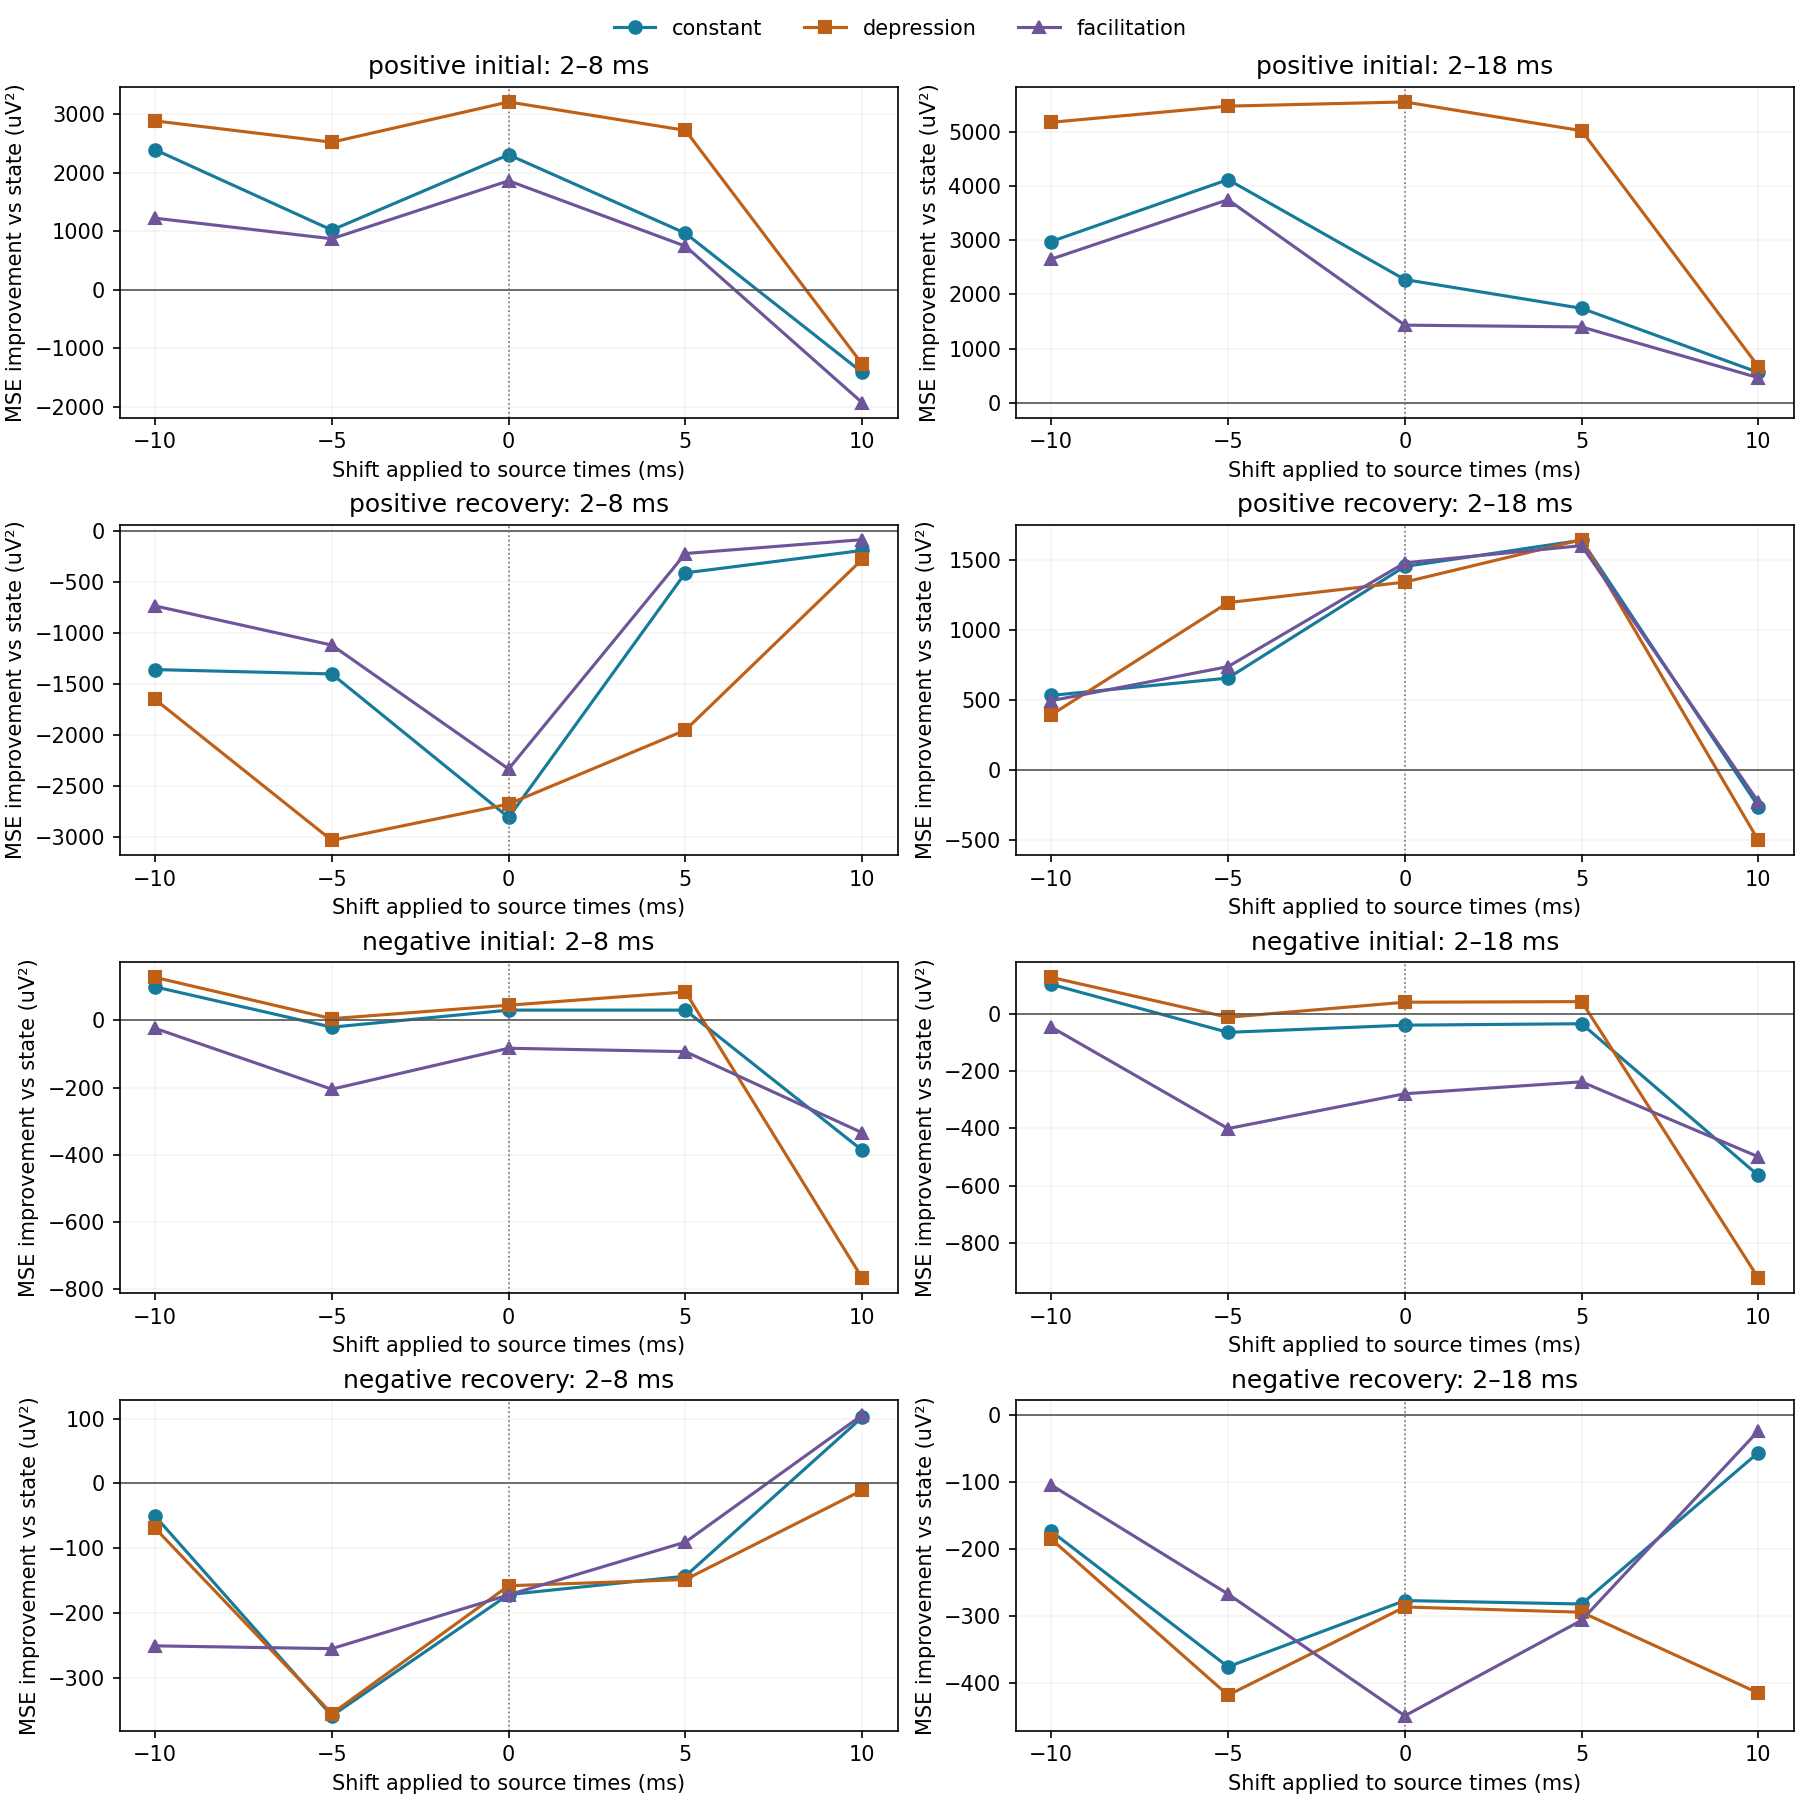

In [3]:
fig,axes = plt.subplots(4,2,figsize=(12,12),layout='constrained')
methods = ('constant','depression','facilitation')
colors = ('#167A9B','#BE6018','#6E5599')
markers = ('o','s','^')
shifts = results['prefix']['design']['shifts_ms']
for row_index,(target,region) in enumerate((('positive','initial'),('positive','recovery'),('negative','initial'),('negative','recovery'))):
    for col,window in enumerate(('short','long')):
        ax = axes[row_index,col]
        for method,color,marker in zip(methods,colors,markers):
            values = [next(r['comparators']['state_only']['mean_gain_uV2'] for r in results['prefix']['summary'] if
                r['cohort']=='temporal' and r['target']==target and r['region']==region and r['window']==window and r['method']==method and r['shift_ms']==shift) for shift in shifts]
            ax.plot(shifts,values,color=color,marker=marker,label=method)
        ax.axhline(0,color='#555555',linewidth=.8)
        ax.axvline(0,color='#777777',linestyle=':',linewidth=.8)
        ax.set(title=f'{target} {region}: '+('2–8 ms' if window=='short' else '2–18 ms'),
               xlabel='Shift applied to source times (ms)',ylabel='MSE improvement vs state (uV²)',xticks=shifts)
        ax.grid(alpha=.12)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=3,frameon=False)
fig.savefig(folder/'figures/source_timing_phase.png',dpi=150)
display(Image(filename=str(folder/'figures/source_timing_phase.png')))
plt.close(fig)


### Observation budget changes the recovery comparison
The target outcomes and scored bins are identical between the two budgets.
Masked history sometimes forces the predictor to rely on an old voltage; full
prefix restores available past observations. Both still withhold the current
response. Bars start at zero, with separate scales per panel.


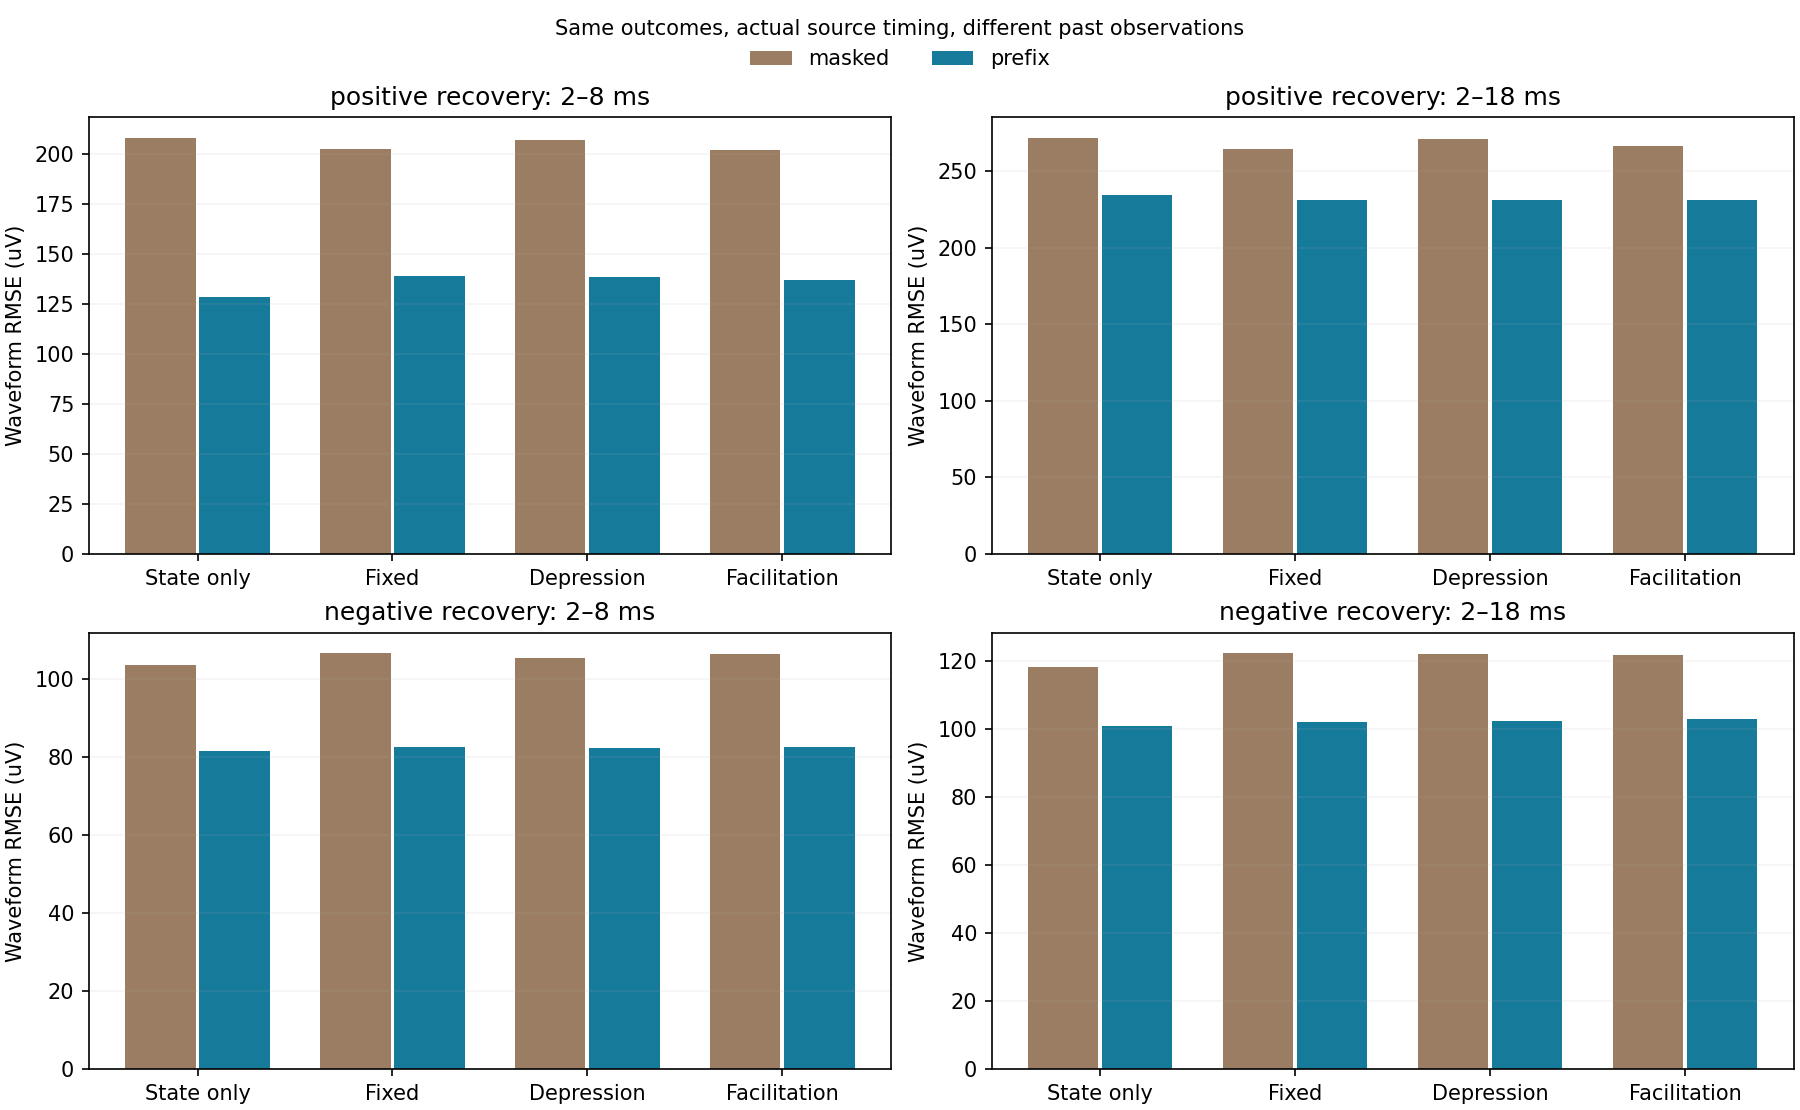

In [4]:
fig,axes = plt.subplots(2,2,figsize=(12,7.4),layout='constrained')
methods = ('none','constant','depression','facilitation')
for row_index,target in enumerate(('positive','negative')):
    for col,window in enumerate(('short','long')):
        ax = axes[row_index,col]
        for offset,label,color in ((-.19,'masked','#9A7D62'),(.19,'prefix','#167A9B')):
            values = [next(r['waveform_rmse_uV'] for r in results[label]['summary'] if r['cohort']=='temporal' and
                r['target']==target and r['window']==window and r['region']=='recovery' and r['shift_ms']==0 and r['method']==m) for m in methods]
            ax.bar(np.arange(4)+offset,values,width=.36,label=label,color=color)
        ax.set_xticks(np.arange(4),('State only','Fixed','Depression','Facilitation'))
        ax.set(title=f'{target} recovery: '+('2–8 ms' if window=='short' else '2–18 ms'),ylabel='Waveform RMSE (uV)')
        ax.set_ylim(bottom=0)
        ax.grid(axis='y',alpha=.12)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=2,frameon=False,title='Same outcomes, actual source timing, different past observations')
fig.savefig(folder/'figures/source_timing_budget.png',dpi=150)
display(Image(filename=str(folder/'figures/source_timing_budget.png')))
plt.close(fig)


### Time-resolved actual and predicted responses
Full-prefix long-window traces are shown relative to each available voltage anchor.
For display only, average the 31 ordered native bins within each pulse and then
across sweeps. The x coordinate is the mean actual post-AP bin-center time; small
sub-bin timing differences remain. Metrics use the original timestamps, with no
interpolation. Shading is between-sweep SD of each sweep's mean trace, not a
confidence interval. All displayed predictions use actual source timing.


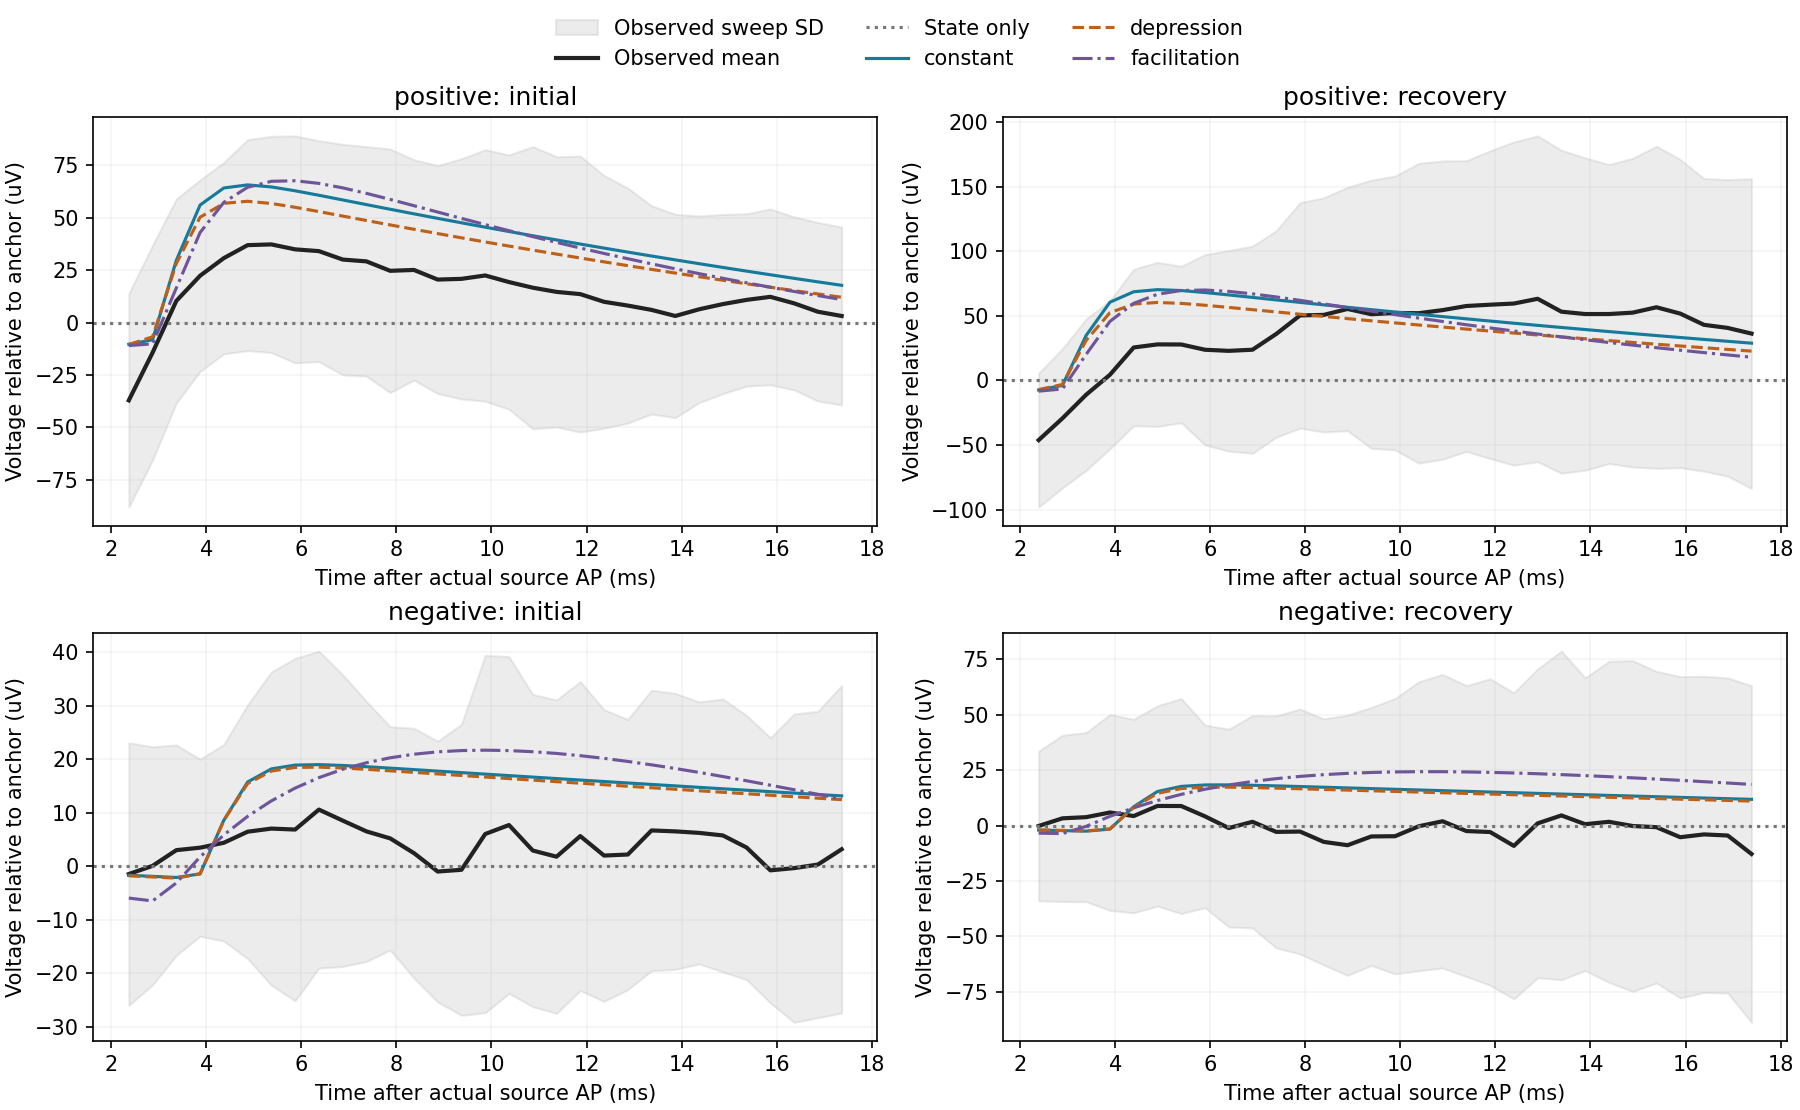

In [5]:
fig,axes = plt.subplots(2,2,figsize=(12,7.4),layout='constrained')
z = arrays['prefix']
for row_index,target in enumerate(('positive','negative')):
    for col,region in enumerate(('initial','recovery')):
        ax = axes[row_index,col]
        observations,times = [],[]
        predicted = {m:[] for m in ('constant','depression','facilitation')}
        pulse_ids = range(8) if region=='initial' else range(8,12)
        for sweep in range(47,57):
            key = 'long_'+str(sweep)+'_'+target
            masks = [z[key+'_pulses']==pulse for pulse in pulse_ids]
            assert all(mask.sum()==31 for mask in masks)
            observations.append(np.mean([z[key+'_innovation'][mask] for mask in masks],axis=0))
            times.append(np.mean([z[key+'_relative_ms'][mask] for mask in masks],axis=0))
            for method in predicted:
                predicted[method].append(np.mean([z[key+'_shift0_'+method][mask] for mask in masks],axis=0))
        observed = np.array(observations)
        x = np.mean(times,axis=0)
        mean,sd = observed.mean(axis=0),observed.std(axis=0,ddof=1)
        ax.fill_between(x,mean-sd,mean+sd,color='#999999',alpha=.18,label='Observed sweep SD')
        ax.plot(x,mean,color='#222222',linewidth=2,label='Observed mean')
        ax.axhline(0,color='#777777',linestyle=':',label='State only')
        for method,color,style in zip(predicted,('#167A9B','#BE6018','#6E5599'),('-','--','-.')):
            ax.plot(x,np.mean(predicted[method],axis=0),color=color,linestyle=style,label=method)
        ax.set(title=f'{target}: {region}',xlabel='Time after actual source AP (ms)',ylabel='Voltage relative to anchor (uV)')
        ax.grid(alpha=.12)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=3,frameon=False)
fig.savefig(folder/'figures/source_timing_waveforms.png',dpi=150)
display(Image(filename=str(folder/'figures/source_timing_waveforms.png')))
plt.close(fig)


## Takeaways
Actual-time predictive gains, timing specificity and activity-dependent efficacy
are separate questions. A source-time preference does not by itself identify a
synaptic mechanism, and a small improvement over a fixed kernel can still lose
to state-only prediction. Check both initial and recovery outcomes and both
targets. An observation-budget-dependent gain is not stable mechanistic evidence.

The source-command artifact guard and negative target are useful controls, but do
not exclude all common inputs or recording effects. Shift/latency compensation,
regular 50 Hz timing and boundary parameters limit physical delay identification.
No physiological conductance or Riemannian metric is estimated by this analysis.

All five code cells execute in order; figures and exact-value tables above are
saved outputs. Raw arrays, fitted choices and both observation budgets remain
available without rerunning or overwriting either analysis.
